Name:Akshat Jain
Enrollment:0801CS231013
Perform the following tasks on the shared dataset.
a) Basic Exploratory Data Analysis
b) Visualization
c) Data Wrangling/Preprocessing
d) Apply all the three Models( Multiple Linear regression, SGDRegressor, Lasso Regression)
e) Evaluate
f) Tune HyperParameter
g) Save the model parameter

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/01_final_wheat_data.xlsx - final_wheat_data.csv")

In [ ]:
df.shape

(6003, 12)

In [ ]:
df.columns

Index(['commodity', 'category', 'item', 'item2', 'units', 'size', 'region',
       'country', 'year', 'value', 'survey_base_year', 'note'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6003 entries, 0 to 6002
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   commodity         6003 non-null   object 
 1   category          6003 non-null   object 
 2   item              6000 non-null   object 
 3   item2             6001 non-null   object 
 4   units             6002 non-null   object 
 5   size              5999 non-null   object 
 6   region            6001 non-null   object 
 7   country           6001 non-null   object 
 8   year              5999 non-null   float64
 9   value             6003 non-null   float64
 10  survey_base_year  6003 non-null   object 
 11  note              618 non-null    object 
dtypes: float64(2), object(10)
memory usage: 562.9+ KB


In [ ]:
df.describe(include="all")

,commodity,category,item,item2,units,size,region,country,year,value,survey_base_year,note
count,6003,6003,6000,6001,6002,5999,6001,6001,5999.000000,6003.000000,6003,618
unique,1,7,35,35,5,1,9,1,NaN,NaN,5,3
top,Wheat,Operating costs,"Total, gross value of production","Secondary product, silage/straw/grazing",dollars per planted acre,No specific size,U.S. total,United States,NaN,NaN,Base survey of 2009,"鲁For 2022-2024 estimates, insufficient data fo..."
freq,6003,1809,201,201,4421,5999,810,6001,NaN,NaN,1680,216
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.320053,75.708191,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.937081,129.087266,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998.000000,-196.080000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003.000000,6.315000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.000000,20.920000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,95.000000,NaN,NaN


**VISUALISATION**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

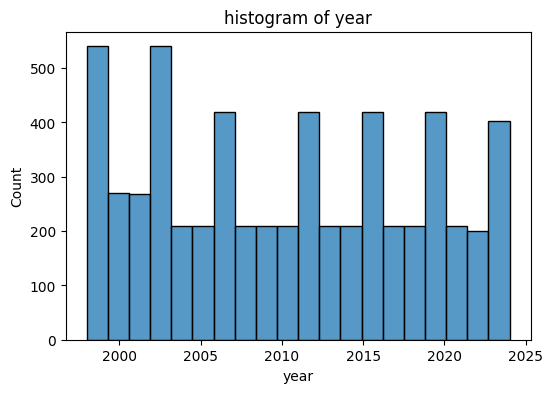

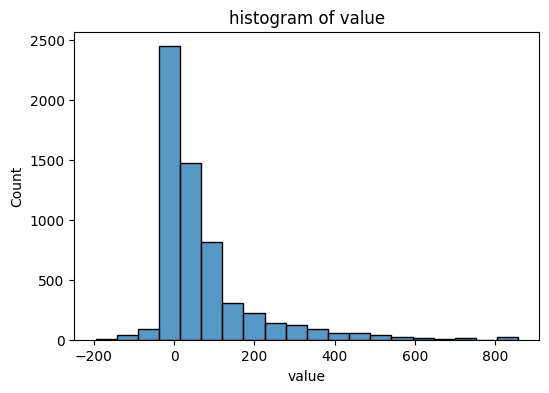

In [ ]:
for col in df.select_dtypes(include=['float64']).columns:
  plt.figure(figsize=(6,4))
  sns.histplot(x=df[col],bins=20)
  plt.title(f'histogram of {col}')
  plt.show()


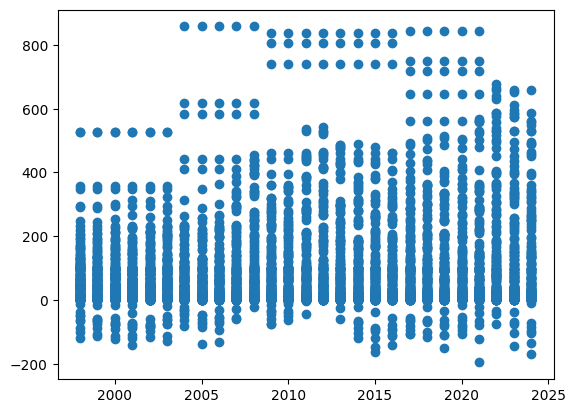

In [ ]:
#scatter plot
x=df["year"]
y=df["value"]
plt.scatter(x,y)

<Axes: xlabel='year', ylabel='value'>

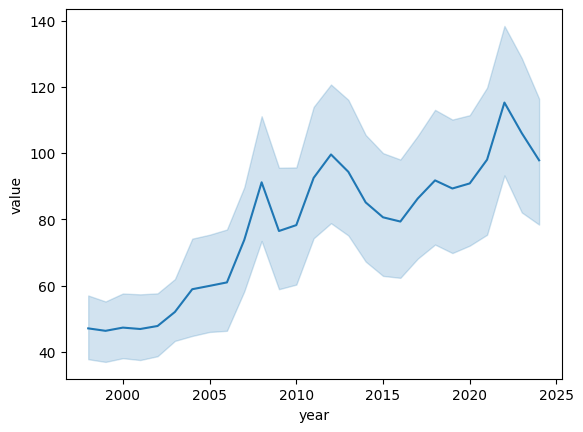

In [ ]:
sns.lineplot(x=df['year'],y=df['value'])

In [ ]:
df.item.value_counts()

,count
item,
"Total, gross value of production",201
Fertilizer 鹿,201
Seed,201
"Total, costs listed",201
Value of production less total costs listed,201
Chemicals,201
Custom services,201
"Fuel, lube, and electricity",201
Repairs,201


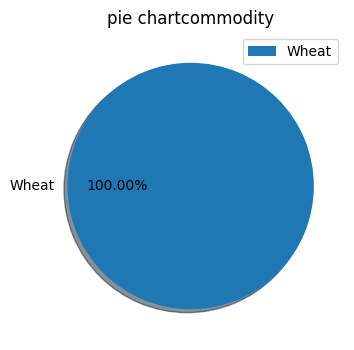

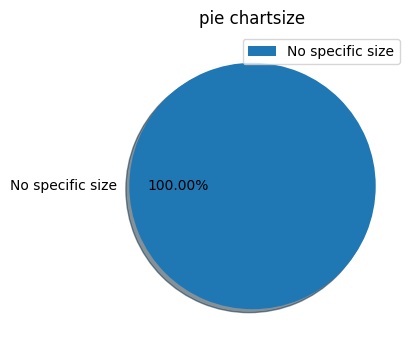

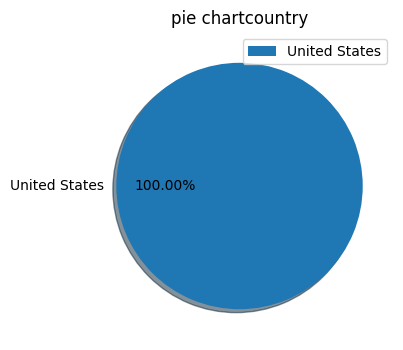

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40065 (\N{CJK UNIFIED IDEOGRAPH-9C81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40575 (\N{CJK UNIFIED IDEOGRAPH-9E7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 34383 (\N{CJK UNIFIED IDEOGRAPH-864F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


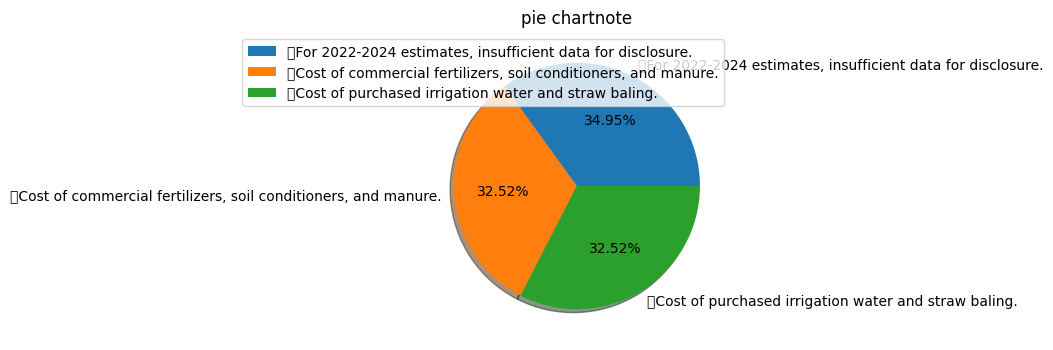

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
  if(len(df[col].value_counts())<=4):
    plt.figure(figsize=(6,4))
    plt.pie(df[col].value_counts().values,
    labels=df[col].value_counts().index,
    shadow= True,autopct='%1.2f%%')
    plt.legend()
    plt.title(f'pie chart{col}')
    plt.show()


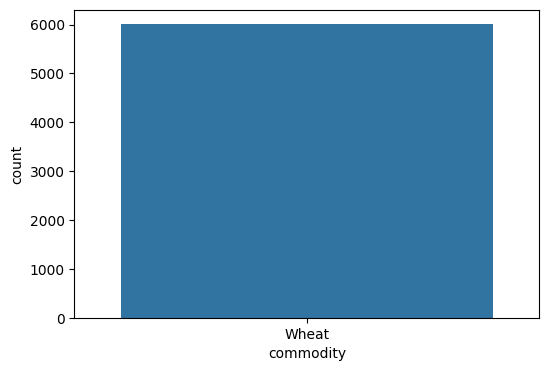

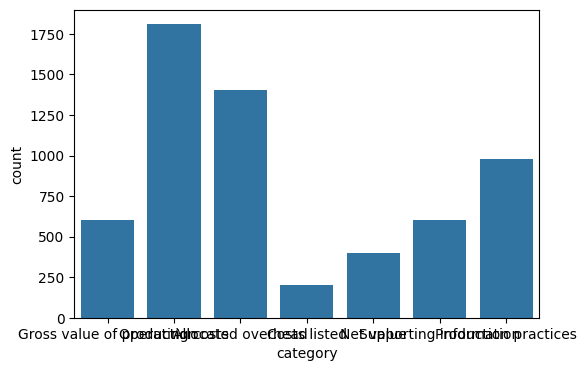

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40575 (\N{CJK UNIFIED IDEOGRAPH-9E7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 34383 (\N{CJK UNIFIED IDEOGRAPH-864F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40065 (\N{CJK UNIFIED IDEOGRAPH-9C81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


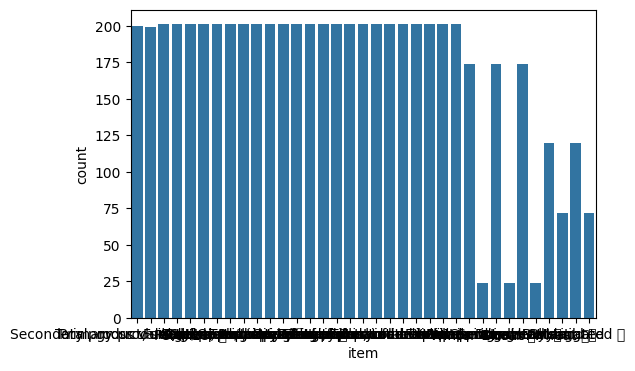

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40575 (\N{CJK UNIFIED IDEOGRAPH-9E7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 34383 (\N{CJK UNIFIED IDEOGRAPH-864F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40065 (\N{CJK UNIFIED IDEOGRAPH-9C81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


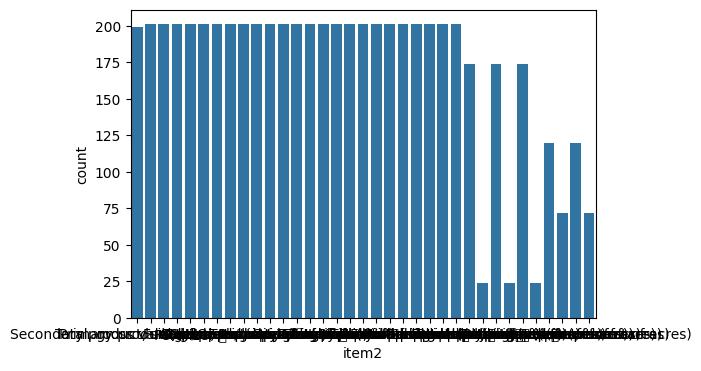

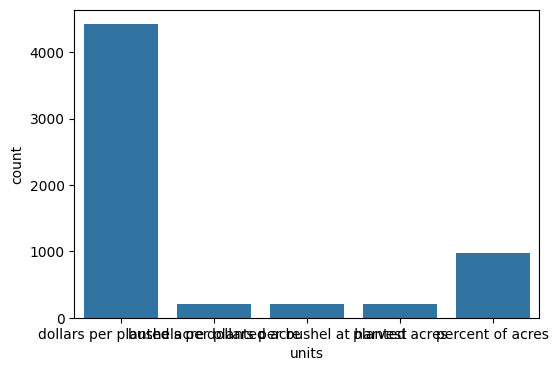

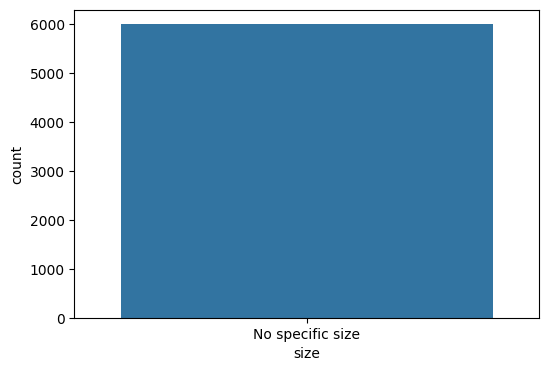

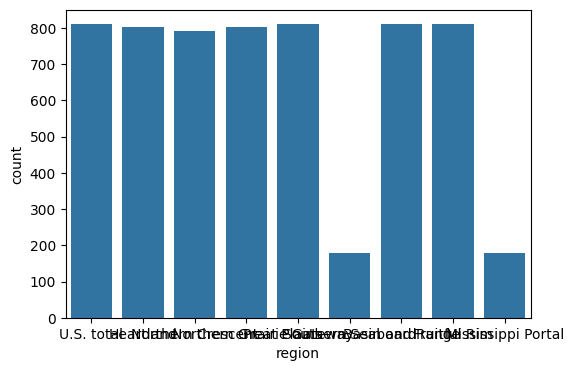

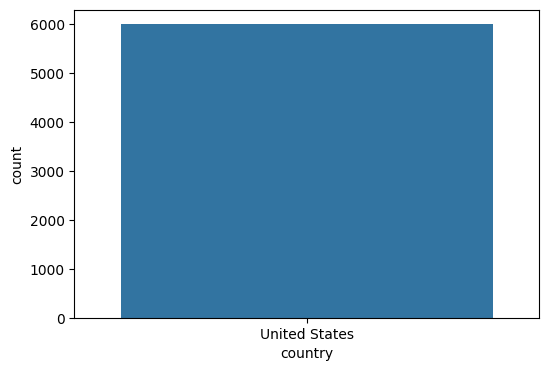

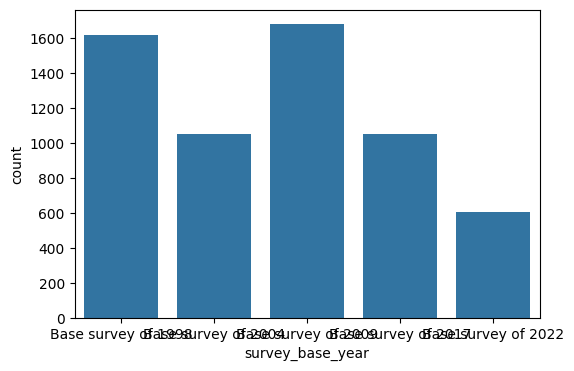

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40575 (\N{CJK UNIFIED IDEOGRAPH-9E7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 34383 (\N{CJK UNIFIED IDEOGRAPH-864F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40065 (\N{CJK UNIFIED IDEOGRAPH-9C81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


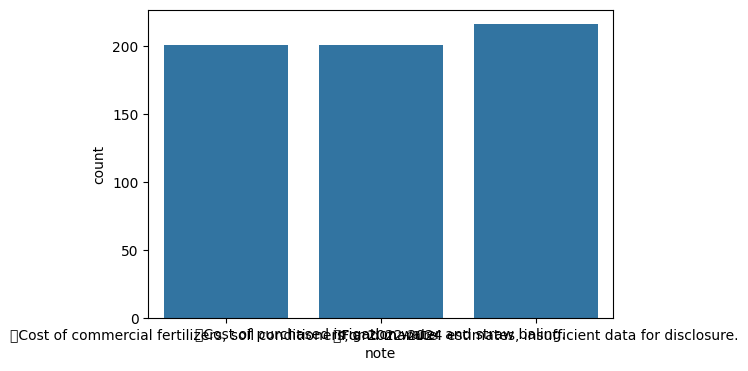

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
  plt.figure(figsize=(6,4))
  sns.countplot(x=df[col],data=df)
  plt.show()

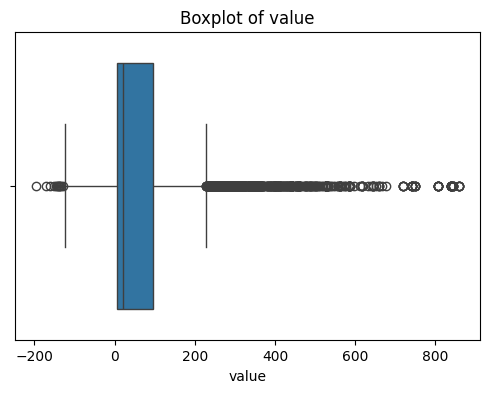

In [ ]:
#detect outliers without boxplot

numerical_cols = df.select_dtypes(include=['number']).columns
features_with_outliers = []

for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  if not outliers.empty:
    features_with_outliers.append(col)

for col in features_with_outliers:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=col, data=df)
  plt.title(f'Boxplot of {col}')
  plt.show()

In [ ]:
for col in features_with_outliers:
  Q1=df[col].quantile(0.05)
  Q3=df[col].quantile(0.95)


  df[col]=df[col].clip(lower=Q1 , upper=Q3)

/tmp/ipython-input-3213581802.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


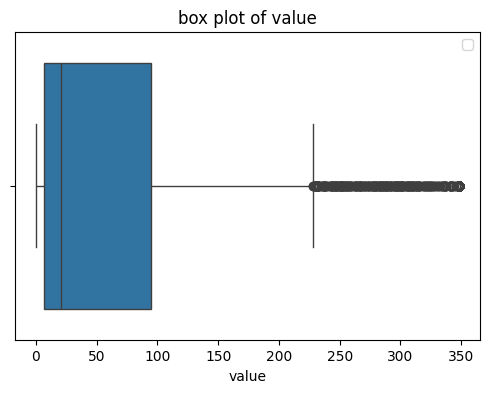

In [ ]:
for cols in features_with_outliers:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[cols],data=df)
  plt.legend()
  plt.title(f'box plot of {cols}')
  plt.show()

In [ ]:
corr_matrix=df.corr(numeric_only=True)
print(corr_matrix)


          year    value
year   1.00000  0.14862
value  0.14862  1.00000


<Axes: >

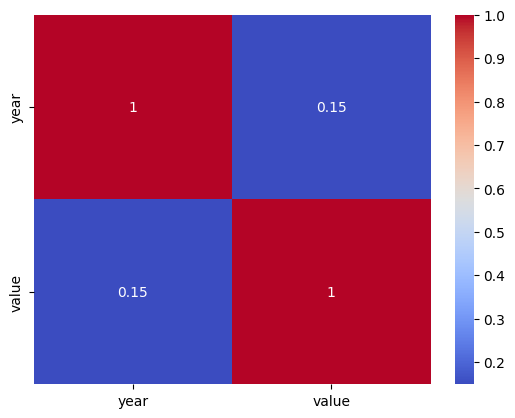

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6003 entries, 0 to 6002
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   commodity         6003 non-null   object 
 1   category          6003 non-null   object 
 2   item              6000 non-null   object 
 3   item2             6001 non-null   object 
 4   units             6002 non-null   object 
 5   size              5999 non-null   object 
 6   region            6001 non-null   object 
 7   country           6001 non-null   object 
 8   year              5999 non-null   float64
 9   value             6003 non-null   float64
 10  survey_base_year  6003 non-null   object 
 11  note              618 non-null    object 
dtypes: float64(2), object(10)
memory usage: 562.9+ KB


In [ ]:
df.isna().sum()

,0
commodity,0
category,0
item,3
item2,2
units,1
size,4
region,2
country,2
year,4
value,0


<Axes: >

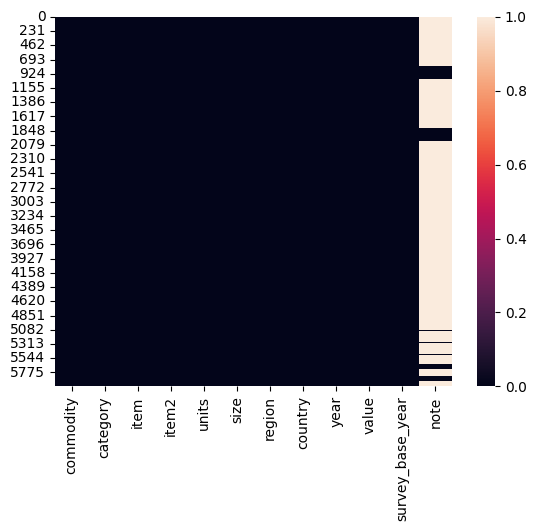

In [ ]:
sns.heatmap(df.isnull())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6003 entries, 0 to 6002
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   commodity         6003 non-null   object 
 1   category          6003 non-null   object 
 2   item              6000 non-null   object 
 3   item2             6001 non-null   object 
 4   units             6002 non-null   object 
 5   size              5999 non-null   object 
 6   region            6001 non-null   object 
 7   country           6001 non-null   object 
 8   year              5999 non-null   float64
 9   value             6003 non-null   float64
 10  survey_base_year  6003 non-null   object 
 11  note              618 non-null    object 
dtypes: float64(2), object(10)
memory usage: 562.9+ KB


In [ ]:
df['item']=df['item'].fillna(df['item'].mode()[0])
df['item2']=df['item2'].fillna(df['item2'].mode()[0])
df['units']=df['units'].fillna(df['units'].mode()[0])
df['size']=df['size'].fillna(df['size'].mode()[0])
df['region']=df['region'].fillna(df['region'].mode()[0])
df['country']=df['country'].fillna(df['country'].mode()[0])
df['note']=df['note'].fillna(df['note'].mode()[0])



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6003 entries, 0 to 6002
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   commodity         6003 non-null   object 
 1   category          6003 non-null   object 
 2   item              6003 non-null   object 
 3   item2             6003 non-null   object 
 4   units             6003 non-null   object 
 5   size              6003 non-null   object 
 6   region            6003 non-null   object 
 7   country           6003 non-null   object 
 8   year              5999 non-null   float64
 9   value             6003 non-null   float64
 10  survey_base_year  6003 non-null   object 
 11  note              6003 non-null   object 
dtypes: float64(2), object(10)
memory usage: 562.9+ KB


In [ ]:
df['year'] = df['year'].fillna(df['year'].median())
df['Age'] = 2026 - df['year']
df.drop('year', axis=1, inplace=True)


In [ ]:
df.drop(['commodity', 'size','note', 'country'], axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
df.head()

,category,item,item2,units,region,value,survey_base_year,Age
0,2,19,19,2,8,110.95,0,28.0
1,2,19,19,2,8,95.73,0,27.0
2,2,19,19,2,8,92.50,0,26.0
3,2,19,19,2,8,95.22,0,25.0
4,2,19,19,2,8,91.51,0,24.0


In [ ]:
y = df['value']
X = df.drop('value', axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
for col in X_train.columns:
    mean_val = X_train[col].mean()
    std_val = X_train[col].std()

    X_train[col] = (X_train[col] - mean_val) / (std_val )
    X_test[col] = (X_test[col] - mean_val) / (std_val )

In [ ]:

from sklearn.linear_model import LinearRegression
lin = LinearRegression()
lin.fit(X_train, y_train)
lin.intercept_




np.float64(68.93670179092045)

In [ ]:
y_pred

array([213.70040869, 113.48520541, 139.82694696, ...,  12.93724756,
        74.65773847, 190.77130564])

In [ ]:
from sklearn.metrics import mean_squared_error
print("Training R2 Score:", lin.score(X_train, y_train))
print("Testing R2 Score:", lin.score(X_test, y_test))
print("Mean squared error on tes data",mean_squared_error(y_test,y_pred))

Training R2 Score: 0.17975003528397349
Testing R2 Score: 0.17266618995063154
Mean squared error on tes data 8394.750028589526


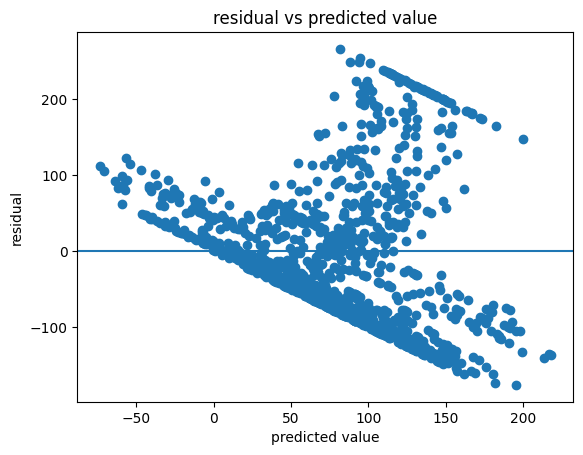

In [ ]:
residuals =y_test - y_pred
plt.scatter(y_pred ,residuals)
plt.axhline(y=0)
plt.xlabel("predicted value")
plt.ylabel("residual")
plt.title("residual vs predicted value")
plt.show()

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
print("ridge train r2",ridge.score(X_train,y_train))
print("ridge test r2",ridge.score(X_test,y_test))

ridge train r2 0.17974939368475695
ridge test r2 0.17266306740913862


In [ ]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
print("Lasso Train R2:", lasso.score(X_train, y_train))
print("Lasso Test R2:", lasso.score(X_test, y_test))
importance = pd.Series(lasso.coef_, index=X_train.columns)
print("\nLasso Coefficients:\n", importance)

Lasso Train R2: 0.17906221371669195
Lasso Test R2: 0.17246580958069568

Lasso Coefficients:
 category           -14.408099
item                29.184870
item2                0.998025
units               27.255676
region              -6.193593
survey_base_year     4.434972
Age                 -9.809810
dtype: float64


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid={'alpha':[0.001,0.01,0.1,1,10,100]}
grid=GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='r2',
    cv=5
)
grid.fit(X_train,y_train)


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [ ]:
print("Best alpha:" ,grid.best_params_)
print("best cv r2 score:" ,grid.best_score_)

Best alpha: {'alpha': 100}
best cv r2 score: 0.1772975884989613


In [ ]:
best_ridge = grid.best_estimator_

print("Ridge Train r2: ", best_ridge.score(X_train, y_train))
print("Ridge Test r2: ", best_ridge.score(X_test, y_test))

Ridge Train r2:  0.1795858712451408
Ridge Test r2:  0.17233300890352932
